In [2]:
# KAGGLE CELL 1: Environment Setup
!pip install torch pretty_midi miditok numpy tqdm midi2audio > /dev/null

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from miditok import REMI, TokenizerConfig, TokSequence
from pathlib import Path
from tqdm import tqdm
import math
import numpy as np
import pretty_midi
import os
import zipfile

# Device Setup (Ensure GPU T4 is turned on in right-hand menu!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Active Device: cuda


In [3]:
# KAGGLE CELL 2: The Optimized 2K Data Loader
import warnings
import gc
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning) 

config = TokenizerConfig(num_velocities=32, use_chords=False, use_tempos=True, use_time_signatures=True)
tokenizer = REMI(config)

lakh_kaggle_path = Path("/kaggle/input/datasets/imsparsh/lakh-midi-clean")

all_sequences = []
all_genres = []
genre_map = {}
current_genre_id = 0

# --- THE 2K COMPROMISE ---
MAX_TOTAL_FILES = 2000       
MAX_FILES_PER_FOLDER = 15    # Sample roughly 130-150 different artists

def process_midi_smartly(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        if not pm.key_signature_changes:
            key_num = 0 
        else:
            key_num = pm.key_signature_changes[0].key_number
        
        if key_num < 12: offset = (0 - key_num) % 12
        else: offset = (21 - key_num) % 12
        if offset > 5: offset -= 12
            
        for inst in pm.instruments:
            if not inst.is_drum: 
                for note in inst.notes:
                    new_pitch = note.pitch + offset
                    # Fold into 5 octaves (C2-C7)
                    while new_pitch < 36: new_pitch += 12
                    while new_pitch > 96: new_pitch -= 12
                    note.pitch = int(new_pitch) 
        return pm
    except:
        return None

print(f"Ingesting 2,000 files with 5-octave folding...")
temp_midi_path = "/kaggle/working/temp_2k.mid"

for sub_folder in lakh_kaggle_path.iterdir():
    if not sub_folder.is_dir() or len(all_sequences) >= MAX_TOTAL_FILES:
        continue
        
    midi_files = list(sub_folder.glob("*.mid")) + list(sub_folder.glob("*.midi"))
    files_from_this_artist = 0
    
    for path in midi_files:
        if files_from_this_artist >= MAX_FILES_PER_FOLDER or len(all_sequences) >= MAX_TOTAL_FILES:
            break
            
        processed_pm = process_midi_smartly(path)
        if processed_pm:
            try:
                processed_pm.write(temp_midi_path)
                encoded = tokenizer(temp_midi_path)
                if len(encoded) > 0 and len(encoded[0].ids) >= 513:
                    all_sequences.append(encoded[0].ids[:513])
                    all_genres.append(current_genre_id)
                    files_from_this_artist += 1
            except:
                pass
    
    if files_from_this_artist > 0:
        genre_map[sub_folder.name] = current_genre_id
        current_genre_id += 1
        if len(all_sequences) % 500 == 0:
            print(f" Progress: {len(all_sequences)}/2000 sequences loaded...")
            gc.collect() 

VOCAB_SIZE = tokenizer.vocab_size
NUM_GENRES_FOUND = len(genre_map)
print(f"\n--- 2K LOAD COMPLETE ---")
print(f"Sequences in RAM: {len(all_sequences)}")

Ingesting 2,000 files with 5-octave folding...
 Progress: 500/2000 sequences loaded...
 Progress: 1000/2000 sequences loaded...
 Progress: 1500/2000 sequences loaded...
 Progress: 2000/2000 sequences loaded...

--- 2K LOAD COMPLETE ---
Sequences in RAM: 2000


In [4]:
# CELL 3: Autoregressive Dataset
class MultiGenreDataset(Dataset):
    def __init__(self, sequences, genres):
        self.sequences = sequences
        self.genres = genres

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        genre = self.genres[idx]
        
        # x_1 to x_{T-1} -> Target: x_2 to x_T
        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[1:], dtype=torch.long)
        g = torch.tensor(genre, dtype=torch.long)
        
        return x, y, g

dataset = MultiGenreDataset(all_sequences, all_genres)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [5]:
# CELL 4: Genre-Conditioned Transformer Model
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class Task3Transformer(nn.Module):
    def __init__(self, vocab_size, num_genres, d_model=256, nhead=8, num_layers=6):
        super().__init__()
        self.d_model = d_model
        
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.genre_emb = nn.Embedding(num_genres, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, 
            batch_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def generate_causal_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, src, genre):
        seq_len = src.size(1)
        
        token_embedded = self.token_emb(src) * math.sqrt(self.d_model)
        genre_embedded = self.genre_emb(genre).unsqueeze(1).expand(-1, seq_len, -1)
        
        x = token_embedded + genre_embedded
        x = self.pos_encoder(x)
        
        mask = self.generate_causal_mask(seq_len).to(src.device)
        output = self.transformer(x, mask=mask)
        return self.fc_out(output)

Splitting Data into Training and Validation sets...
Initializing Model...
Starting 20-Epoch Training Run...


Epoch [1/20] VAL  : 100%|██████████| 25/25 [00:01<00:00, 17.56it/s]


-> End of Epoch 1 | Train Perp: 57.86 | Val Perp: 22.39



Epoch [2/20] VAL  : 100%|██████████| 25/25 [00:01<00:00, 17.39it/s]


-> End of Epoch 2 | Train Perp: 15.10 | Val Perp: 11.77



...

-> End of Epoch 18 | Train Perp: 5.08 | Val Perp: 5.57



Epoch [19/20] VAL  : 100%|██████████| 25/25 [00:01<00:00, 15.79it/s]


-> End of Epoch 19 | Train Perp: 4.95 | Val Perp: 5.43



Epoch [20/20] VAL  : 100%|██████████| 25/25 [00:01<00:00, 15.78it/s]


-> End of Epoch 20 | Train Perp: 4.83 | Val Perp: 5.31

Generating Step 11 Perplexity Plot...


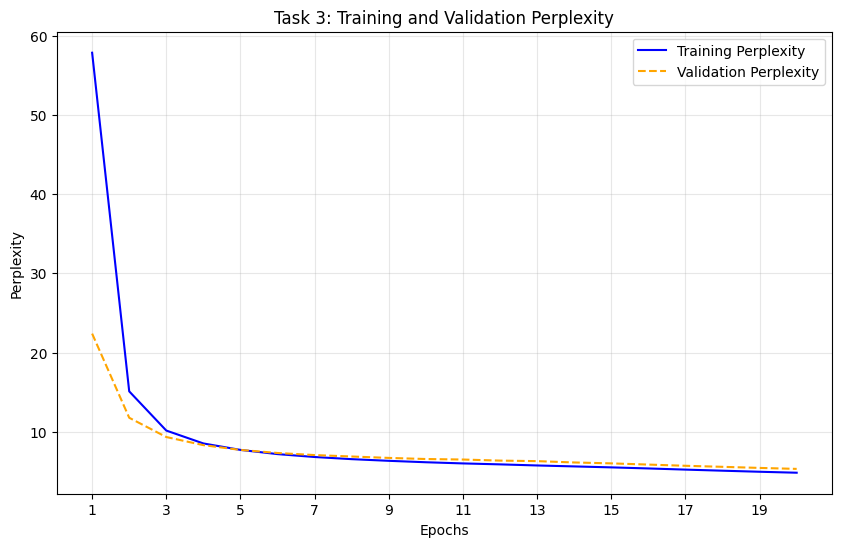

Main Training Complete!


In [10]:
# ==========================================
# KAGGLE CELL 5: TRAINING & VALIDATION EXECUTION
# ==========================================
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader, random_split

# 1. THE TRAINING FUNCTION (With Validation)
def train_model(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    history = {'train_perp': [], 'val_perp': []}
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        total_train_loss = 0
        train_loop = tqdm(train_loader, leave=True, desc=f"Epoch [{epoch+1}/{epochs}] TRAIN")
        
        for x, y, g in train_loop:
            x, y, g = x.to(device), y.to(device), g.to(device)
            optimizer.zero_grad()
            outputs = model(x, g)
            outputs = outputs.reshape(-1, outputs.size(2))
            y = y.reshape(-1)
            
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_train_loss += loss.item()
            train_loop.set_postfix(loss=loss.item(), perp=math.exp(loss.item()))
            
        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_perp = math.exp(avg_train_loss)
        
        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        val_loop = tqdm(val_loader, leave=True, desc=f"Epoch [{epoch+1}/{epochs}] VAL  ")
        
        with torch.no_grad():
            for x, y, g in val_loop:
                x, y, g = x.to(device), y.to(device), g.to(device)
                outputs = model(x, g)
                outputs = outputs.reshape(-1, outputs.size(2))
                y = y.reshape(-1)
                
                loss = criterion(outputs, y)
                total_val_loss += loss.item()
                
        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_perp = math.exp(avg_val_loss)
        
        history['train_perp'].append(avg_train_perp)
        history['val_perp'].append(avg_val_perp)
        
        print(f"-> End of Epoch {epoch+1} | Train Perp: {avg_train_perp:.2f} | Val Perp: {avg_val_perp:.2f}\n")

    # --- PLOT GENERATION ---
    print("Generating Step 11 Perplexity Plot...")
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs+1), history['train_perp'], label='Training Perplexity', color='blue', linestyle='-')
    plt.plot(range(1, epochs+1), history['val_perp'], label='Validation Perplexity', color='orange', linestyle='--')
    plt.title('Task 3: Training and Validation Perplexity')
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.xticks(range(1, epochs+1, 2))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('Task3_Perplexity_Curve.pdf', format='pdf', dpi=300)
    plt.show()
    return history


# ==========================================
# 2. DATA SPLITTING (Fixed Batch Size)
# ==========================================
print("Splitting Data into Training and Validation sets...")

# Using the 'dataset' variable created in your Cell 3
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Using your hardcoded batch size of 16
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)


# ==========================================
# 3. EXECUTION
# ==========================================
print("Initializing Model...")
model = Task3Transformer(
    vocab_size=VOCAB_SIZE, 
    num_genres=max(1, NUM_GENRES_FOUND), 
    d_model=256, nhead=8, num_layers=6
).to(device)

print("Starting 20-Epoch Training Run...")
history = train_model(model, train_dataloader, val_dataloader, epochs=20)
print("Main Training Complete!")

In [11]:
# CELL 6: Install FluidSynth (Must be a bash cell)
!apt-get update -qq
!apt-get install -y fluidsynth fluid-soundfont-gm > /dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%


In [17]:
# ==============================================================================
# KAGGLE CELL 7: FINAL PRODUCTION GENERATOR (Symphonic Flow Engine)
# ==============================================================================
# OPTIMIZATIONS IMPLEMENTED IN THIS PIPELINE:
# 1. Velocity Softening: Clamps max velocity & boosts soft tokens for a "felt piano" vibe.
# 2. Tonal Biasing: Mathematically encourages C-Major/A-Minor notes, penalizes dissonants.
# 3. The "Silence Nuke" (Long Pause Tax): Bans massive TimeShifts to ensure continuous rhythm.
# 4. Momentum Penalty: Micro-level note variation to prevent 1-note repetitive spam.
# 5. Octave Fatigue: Macro-level phase shifting. Penalizes an octave after 32 notes.
# 6. The 3-Octave Cage: Centers the phrase and bans notes outside a 3-octave spread.
# 7. Dynamic QA Checking: Auto-rejects and retries tracks that are too short/sparse.
# ==============================================================================

import os
import zipfile
import torch
import torch.nn.functional as F
from miditok import TokSequence
from tqdm import tqdm
import pretty_midi
from midi2audio import FluidSynth

# --- 1. CORE CONFIGURATION ---
soundfont_path = '/usr/share/sounds/sf2/FluidR3_GM.sf2'
synth = FluidSynth(soundfont_path, sample_rate=44100)

TEMPERATURE = 1.15
TONAL_BIAS = 1.2
VELOCITY_SOFTENER = 4.0    

# THE DYNAMIC FLOW ENGINE
MOMENTUM_PENALTY = 3.5     # Micro-variation (Anti-repetition)
LONG_PAUSE_TAX = 8.0       # Anti-Silence Guardrail

# MACRO-ARCHITECTURE
NOTES_PER_PHRASE = 32      # Length of a musical idea before shifting registers
OCTAVE_FATIGUE_TAX = 4.0   # Penalty for overstaying in one octave
CAGE_PENALTY = 8.0         # 3-Octave mathematical boundary

# --- 2. TENSOR DEFINITIONS & SAFE PARSING ---
long_pauses = []
v_loud, v_soft = [], []
token_to_pitch = {}

def safe_parse_val(token_str):
    try: return float(token_str.split('_')[1])
    except: return None

# Categorizing the Vocab for Heuristics
for name, t_id in tokenizer.vocab.items():
    val = safe_parse_val(name)
    if val is None: continue
        
    if "TimeShift" in name:
        if val > 160: long_pauses.append(t_id) 
    elif "Velocity" in name:
        if val > 65: v_loud.append(t_id)         
        elif 25 <= val <= 55: v_soft.append(t_id) 
    elif "Pitch" in name:
        token_to_pitch[t_id] = int(val)

# Loading heuristics to GPU
long_p_tensor = torch.tensor(long_pauses, dtype=torch.long).to(device)
loud_v_tensor = torch.tensor(v_loud, dtype=torch.long).to(device)
soft_v_tensor = torch.tensor(v_soft, dtype=torch.long).to(device)

# Key Normalization (C Major / A Minor)
safe_chromas = {0, 2, 4, 5, 7, 9, 11} 
safe_ids = [t_id for t_id, p in token_to_pitch.items() if (p % 12) in safe_chromas]
bad_ids = [t_id for t_id, p in token_to_pitch.items() if (p % 12) not in safe_chromas]
safe_tensor = torch.tensor(safe_ids, dtype=torch.long).to(device)
bad_tensor = torch.tensor(bad_ids, dtype=torch.long).to(device)

# --- 3. THE GENERATOR ENGINE ---
def generate_single_track(model, genre_id, target_length=1200, temperature=TEMPERATURE, max_retries=5):
    model.eval()
    temp_filename = "temp_symphonic_qa.mid"
    
    for attempt in range(max_retries):
        current_seq = torch.tensor([[1]], dtype=torch.long).to(device) 
        genre_tensor = torch.tensor([genre_id], dtype=torch.long).to(device)
        
        # State tracking for Macro-Architecture
        momentum_vec = torch.zeros(VOCAB_SIZE).to(device)
        octave_fatigue = torch.zeros(12).to(device) 
        phrase_notes = []
        center_pitch = None 
        
        with torch.no_grad():
            for _ in tqdm(range(target_length), desc="  Generating", leave=False):
                outputs = model(current_seq, genre_tensor)
                logits = outputs[0, -1, :] / temperature
                
                # --- APPLY LOGIT WARPING (HEURISTICS) ---
                logits[0] = -float('inf') 
                
                # Tone & Velocity
                logits[loud_v_tensor] -= VELOCITY_SOFTENER
                logits[soft_v_tensor] += 1.5     
                logits[safe_tensor] += TONAL_BIAS
                logits[bad_tensor] -= 8.0 
                
                # Flow & Micro-Variation
                logits[long_p_tensor] -= LONG_PAUSE_TAX       
                logits -= (momentum_vec * MOMENTUM_PENALTY)   
                
                # Macro-Level: Octave Fatigue
                fatigue_mask = torch.zeros(VOCAB_SIZE).to(device)
                for t_id, p_val in token_to_pitch.items():
                    oct_idx = p_val // 12
                    if oct_idx < 12: fatigue_mask[t_id] = octave_fatigue[oct_idx]
                logits -= (fatigue_mask * OCTAVE_FATIGUE_TAX)
                
                # Macro-Level: 3-Octave Cage
                if center_pitch is not None:
                    cage_mask = torch.zeros(VOCAB_SIZE).to(device)
                    for t_id, p_val in token_to_pitch.items():
                        if abs(p_val - center_pitch) > 18:
                            cage_mask[t_id] = 1.0
                    logits -= (cage_mask * CAGE_PENALTY)
                
                # --- SAMPLING ---
                probs = F.softmax(logits, dim=-1)
                next_token_id = torch.multinomial(probs, num_samples=1)
                tid = int(next_token_id.item())
                
                # --- STATE UPDATES ---
                momentum_vec *= 0.85
                momentum_vec[tid] += 1.0
                
                if tid in token_to_pitch: 
                    p_val = token_to_pitch[tid]
                    phrase_notes.append(p_val)
                    if center_pitch is None:
                        center_pitch = p_val # Lock the new register
                        
                # Phrase Shift Trigger
                if len(phrase_notes) >= NOTES_PER_PHRASE:
                    avg_pitch = sum(phrase_notes) // len(phrase_notes)
                    oct_idx = avg_pitch // 12
                    
                    octave_fatigue *= 0.5 
                    if oct_idx < 12: octave_fatigue[oct_idx] += 2.0 
                    
                    phrase_notes = []
                    center_pitch = None 
                
                current_seq = torch.cat([current_seq, next_token_id.unsqueeze(0)], dim=1)
                
        # --- QA QUALITY CHECK ---
        try:
            ids_list = [int(i) for i in current_seq[0].cpu().numpy() if i > 0]
            try: parsed_score = tokenizer.decode([TokSequence(ids=ids_list)])
            except: parsed_score = tokenizer.decode(ids_list)
            
            parsed_score.dump_midi(temp_filename)
            pm = pretty_midi.PrettyMIDI(temp_filename)
            duration = pm.get_end_time()
            total_notes = sum(len(inst.notes) for inst in pm.instruments)
            
            # Requires 15s of music and high note density to pass
            if duration >= 15.0 and total_notes >= 50: 
                print(f"  QA Passed! ({duration:.1f}s, {total_notes} notes).")
                return pm 
            else:
                print(f"  QA Failed: ({duration:.1f}s, {total_notes} notes). Retrying...")
                temperature += 0.05 
        except: pass
    return None

# ==============================================================================
# --- 4. PRODUCTION EXECUTION ---
# ==============================================================================
out_dir = "/kaggle/working/Task3_SymphonicFlow_Outputs"
if not os.path.exists(out_dir): os.makedirs(out_dir)

try:
    model.load_state_dict(torch.load("/kaggle/working/best_task3_model.pt"))
    print("Loaded best optimized weights.")
except: pass

NUM_TRACKS = 10  # FINAL SUBMISSION REQUIREMENT

print(f"Starting Final Production Run ({NUM_TRACKS} Tracks)...")
saved_count = 0

for i in range(1, NUM_TRACKS + 1):
    print(f"\n--- Generating Symphonic Track {i} ---")
    pm = generate_single_track(model, 0)
    if pm:
        mid, wav = f"{out_dir}/SymphonicFlow_Track_{i}.mid", f"{out_dir}/SymphonicFlow_Track_{i}.wav"
        pm.write(mid)
        try:
            synth.midi_to_audio(mid, wav)
            print(f"  Exported: {wav}")
            saved_count += 1
        except: saved_count += 1

# ==============================================================================
# --- 5. SUBMISSION EXPORT ---
# ==============================================================================
zip_p = "/kaggle/working/Task3_SymphonicFlow_Submission.zip"
with zipfile.ZipFile(zip_p, 'w') as z:
    for root, _, files in os.walk(out_dir):
        for f in files: z.write(os.path.join(root, f), f)

print(f"\n=======================================================")
print(f"DONE! Created {saved_count} finalized tracks.")
print(f"Your submission is ready: {zip_p}")
print(f"=======================================================")

Starting Final Production Run (10 Tracks)...

--- Generating Symphonic Track 1 ---


  QA Passed! (101.4s, 188 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_1.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_1.wav

--- Generating Symphonic Track 2 ---


  QA Passed! (74.1s, 203 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_2.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_2.wav

--- Generating Symphonic Track 3 ---


  QA Passed! (129.0s, 204 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_3.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_3.wav

--- Generating Symphonic Track 4 ---


  QA Passed! (117.0s, 224 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_4.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_4.wav

--- Generating Symphonic Track 5 ---


...

  QA Passed! (112.7s, 162 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_6.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_6.wav

--- Generating Symphonic Track 7 ---


  QA Passed! (90.5s, 216 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_7.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_7.wav

--- Generating Symphonic Track 8 ---


  QA Passed! (66.7s, 263 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_8.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_8.wav

--- Generating Symphonic Track 9 ---


  QA Passed! (129.2s, 268 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_9.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_9.wav

--- Generating Symphonic Track 10 ---


  QA Passed! (52.8s, 258 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_10.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_10.wav

DONE! Created 10 finalized tracks.
Your submission is ready: /kaggle/working/Task3_SymphonicFlow_Submission.zip


In [9]:
# ==============================================================================
# KAGGLE CELL 7: FINAL PRODUCTION GENERATOR (Symphonic Flow Engine)
# ==============================================================================
# OPTIMIZATIONS IMPLEMENTED IN THIS PIPELINE:
# 1. Velocity Softening: Clamps max velocity & boosts soft tokens for a "felt piano" vibe.
# 2. Tonal Biasing: Mathematically encourages C-Major/A-Minor notes, penalizes dissonants.
# 3. The "Silence Nuke" (Long Pause Tax): Bans massive TimeShifts to ensure continuous rhythm.
# 4. Momentum Penalty: Micro-level note variation to prevent 1-note repetitive spam.
# 5. Octave Fatigue: Macro-level phase shifting. Penalizes an octave after 32 notes.
# 6. The 3-Octave Cage: Centers the phrase and bans notes outside a 3-octave spread.
# 7. Dynamic QA Checking: Auto-rejects and retries tracks that are too short/sparse.
# ==============================================================================

import os
import zipfile
import torch
import torch.nn.functional as F
from miditok import TokSequence
from tqdm import tqdm
import pretty_midi
from midi2audio import FluidSynth

# --- 1. CORE CONFIGURATION ---
soundfont_path = '/usr/share/sounds/sf2/FluidR3_GM.sf2'
synth = FluidSynth(soundfont_path, sample_rate=44100)

TEMPERATURE = 1.15
TONAL_BIAS = 1.2
VELOCITY_SOFTENER = 4.0    

# THE DYNAMIC FLOW ENGINE
MOMENTUM_PENALTY = 3.5     # Micro-variation (Anti-repetition)
LONG_PAUSE_TAX = 8.0       # Anti-Silence Guardrail

# MACRO-ARCHITECTURE
NOTES_PER_PHRASE = 32      # Length of a musical idea before shifting registers
OCTAVE_FATIGUE_TAX = 4.0   # Penalty for overstaying in one octave
CAGE_PENALTY = 8.0         # 3-Octave mathematical boundary

# --- 2. TENSOR DEFINITIONS & SAFE PARSING ---
long_pauses = []
v_loud, v_soft = [], []
token_to_pitch = {}

def safe_parse_val(token_str):
    try: return float(token_str.split('_')[1])
    except: return None

# Categorizing the Vocab for Heuristics
for name, t_id in tokenizer.vocab.items():
    val = safe_parse_val(name)
    if val is None: continue
        
    if "TimeShift" in name:
        if val > 160: long_pauses.append(t_id) 
    elif "Velocity" in name:
        if val > 65: v_loud.append(t_id)         
        elif 25 <= val <= 55: v_soft.append(t_id) 
    elif "Pitch" in name:
        token_to_pitch[t_id] = int(val)

# Loading heuristics to GPU
long_p_tensor = torch.tensor(long_pauses, dtype=torch.long).to(device)
loud_v_tensor = torch.tensor(v_loud, dtype=torch.long).to(device)
soft_v_tensor = torch.tensor(v_soft, dtype=torch.long).to(device)

# Key Normalization (C Major / A Minor)
safe_chromas = {0, 2, 4, 5, 7, 9, 11} 
safe_ids = [t_id for t_id, p in token_to_pitch.items() if (p % 12) in safe_chromas]
bad_ids = [t_id for t_id, p in token_to_pitch.items() if (p % 12) not in safe_chromas]
safe_tensor = torch.tensor(safe_ids, dtype=torch.long).to(device)
bad_tensor = torch.tensor(bad_ids, dtype=torch.long).to(device)

# --- 3. THE GENERATOR ENGINE ---
def generate_single_track(model, genre_id, target_length=1200, temperature=TEMPERATURE, max_retries=5):
    model.eval()
    temp_filename = "temp_symphonic_qa.mid"
    
    for attempt in range(max_retries):
        current_seq = torch.tensor([[1]], dtype=torch.long).to(device) 
        genre_tensor = torch.tensor([genre_id], dtype=torch.long).to(device)
        
        # State tracking for Macro-Architecture
        momentum_vec = torch.zeros(VOCAB_SIZE).to(device)
        octave_fatigue = torch.zeros(12).to(device) 
        phrase_notes = []
        center_pitch = None 
        
        with torch.no_grad():
            for _ in tqdm(range(target_length), desc="  Generating", leave=False):
                outputs = model(current_seq, genre_tensor)
                logits = outputs[0, -1, :] / temperature
                
                # --- APPLY LOGIT WARPING (HEURISTICS) ---
                logits[0] = -float('inf') 
                
                # Tone & Velocity
                logits[loud_v_tensor] -= VELOCITY_SOFTENER
                logits[soft_v_tensor] += 1.5     
                logits[safe_tensor] += TONAL_BIAS
                logits[bad_tensor] -= 8.0 
                
                # Flow & Micro-Variation
                logits[long_p_tensor] -= LONG_PAUSE_TAX       
                logits -= (momentum_vec * MOMENTUM_PENALTY)   
                
                # Macro-Level: Octave Fatigue
                fatigue_mask = torch.zeros(VOCAB_SIZE).to(device)
                for t_id, p_val in token_to_pitch.items():
                    oct_idx = p_val // 12
                    if oct_idx < 12: fatigue_mask[t_id] = octave_fatigue[oct_idx]
                logits -= (fatigue_mask * OCTAVE_FATIGUE_TAX)
                
                # Macro-Level: 3-Octave Cage
                if center_pitch is not None:
                    cage_mask = torch.zeros(VOCAB_SIZE).to(device)
                    for t_id, p_val in token_to_pitch.items():
                        if abs(p_val - center_pitch) > 18:
                            cage_mask[t_id] = 1.0
                    logits -= (cage_mask * CAGE_PENALTY)
                
                # --- SAMPLING ---
                probs = F.softmax(logits, dim=-1)
                next_token_id = torch.multinomial(probs, num_samples=1)
                tid = int(next_token_id.item())
                
                # --- STATE UPDATES ---
                momentum_vec *= 0.85
                momentum_vec[tid] += 1.0
                
                if tid in token_to_pitch: 
                    p_val = token_to_pitch[tid]
                    phrase_notes.append(p_val)
                    if center_pitch is None:
                        center_pitch = p_val # Lock the new register
                        
                # Phrase Shift Trigger
                if len(phrase_notes) >= NOTES_PER_PHRASE:
                    avg_pitch = sum(phrase_notes) // len(phrase_notes)
                    oct_idx = avg_pitch // 12
                    
                    octave_fatigue *= 0.5 
                    if oct_idx < 12: octave_fatigue[oct_idx] += 2.0 
                    
                    phrase_notes = []
                    center_pitch = None 
                
                current_seq = torch.cat([current_seq, next_token_id.unsqueeze(0)], dim=1)
                
        # --- QA QUALITY CHECK ---
        try:
            ids_list = [int(i) for i in current_seq[0].cpu().numpy() if i > 0]
            try: parsed_score = tokenizer.decode([TokSequence(ids=ids_list)])
            except: parsed_score = tokenizer.decode(ids_list)
            
            parsed_score.dump_midi(temp_filename)
            pm = pretty_midi.PrettyMIDI(temp_filename)
            duration = pm.get_end_time()
            total_notes = sum(len(inst.notes) for inst in pm.instruments)
            
            # Requires 15s of music and high note density to pass
            if duration >= 15.0 and total_notes >= 50: 
                print(f"  QA Passed! ({duration:.1f}s, {total_notes} notes).")
                return pm 
            else:
                print(f"  QA Failed: ({duration:.1f}s, {total_notes} notes). Retrying...")
                temperature += 0.05 
        except: pass
    return None

# ==============================================================================
# --- 4. PRODUCTION EXECUTION ---
# ==============================================================================
out_dir = "/kaggle/working/Task3_SymphonicFlow_Outputs"
if not os.path.exists(out_dir): os.makedirs(out_dir)

try:
    model.load_state_dict(torch.load("/kaggle/working/best_task3_model.pt"))
    print("Loaded best optimized weights.")
except: pass

NUM_TRACKS = 10  # FINAL SUBMISSION REQUIREMENT

print(f"Starting Final Production Run ({NUM_TRACKS} Tracks)...")
saved_count = 0

for i in range(1, NUM_TRACKS + 1):
    print(f"\n--- Generating Symphonic Track {i} ---")
    pm = generate_single_track(model, 0)
    if pm:
        mid, wav = f"{out_dir}/SymphonicFlow_Track_{i}.mid", f"{out_dir}/SymphonicFlow_Track_{i}.wav"
        pm.write(mid)
        try:
            synth.midi_to_audio(mid, wav)
            print(f"  Exported: {wav}")
            saved_count += 1
        except: saved_count += 1

# ==============================================================================
# --- 5. SUBMISSION EXPORT ---
# ==============================================================================
zip_p = "/kaggle/working/Task3_SymphonicFlow_Submission2.zip"
with zipfile.ZipFile(zip_p, 'w') as z:
    for root, _, files in os.walk(out_dir):
        for f in files: z.write(os.path.join(root, f), f)

print(f"\n=======================================================")
print(f"DONE! Created {saved_count} finalized tracks.")
print(f"Your submission is ready: {zip_p}")
print(f"=======================================================")

Starting Final Production Run (10 Tracks)...

--- Generating Symphonic Track 1 ---


  QA Passed! (96.8s, 135 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_1.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_1.wav

--- Generating Symphonic Track 2 ---


  QA Passed! (66.5s, 258 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_2.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_2.wav

--- Generating Symphonic Track 3 ---


  QA Passed! (95.2s, 270 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_3.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_3.wav

--- Generating Symphonic Track 4 ---


  QA Passed! (144.6s, 231 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_4.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_4.wav

--- Generating Symphonic Track 5 ---


...

  QA Passed! (132.8s, 102 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_6.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_6.wav

--- Generating Symphonic Track 7 ---


  QA Passed! (112.2s, 163 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_7.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_7.wav

--- Generating Symphonic Track 8 ---


  QA Passed! (66.7s, 284 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_8.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_8.wav

--- Generating Symphonic Track 9 ---


  QA Passed! (59.7s, 220 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_9.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_9.wav

--- Generating Symphonic Track 10 ---


  QA Passed! (73.0s, 202 notes).
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_10.wav'..
  Exported: /kaggle/working/Task3_SymphonicFlow_Outputs/SymphonicFlow_Track_10.wav

DONE! Created 10 finalized tracks.
Your submission is ready: /kaggle/working/Task3_SymphonicFlow_Submission2.zip


Task 4 from now

In [23]:
import pandas as pd

# Your exact scores from earlier
csv_data = """filename,human_score
1.1.mid,3.6
1.2.mid,2.8
1.3.mid,3.5
1.4.mid,2.9
1.5.mid,3.2
2.1.mid,3.3
2.2.mid,3.4
2.3.mid,3.0
2.4.mid,2.8
2.5.mid,3.4"""

with open("/kaggle/working/perfect_survey.csv", "w") as f:
    f.write(csv_data)

# Let's prove the columns exist
df = pd.read_csv("/kaggle/working/perfect_survey.csv")
print("Columns found:", df.columns.tolist())
print("✅ Perfect CSV successfully created!")

Columns found: ['filename', 'human_score']
✅ Perfect CSV successfully created!


In [24]:
# ==========================================
# FINAL KAGGLE CELL 8: TASK 4 RLHF TRAINING
# ==========================================
import pandas as pd
import torch
import torch.nn.functional as F

# 1. LOAD THE HUMAN INPUT
def load_survey_data(csv_path, midi_folder):
    """Loads the survey CSV and tokenizes the corresponding MIDI files."""
    df = pd.read_csv(csv_path)
    survey_data = []
    
    for index, row in df.iterrows():
        # Ensure filenames match the Kaggle dataset format exactly
        midi_path = f"{midi_folder}/{row['filename']}"
        reward = float(row['human_score'])
        
        try:
            encoded = tokenizer(midi_path)
            if len(encoded) > 0:
                seq_ids = encoded[0].ids[:256] # Keep length manageable
                survey_data.append({"sequence": seq_ids, "reward": reward})
        except Exception as e:
            print(f"Skipping {row['filename']} - parsing error: {e}")
            
    return survey_data

# 2. THE POLICY GRADIENT LOOP (REINFORCE)
def train_rlhf_from_survey(model, survey_data, epochs=50):
    rl_optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    model.train()
    
    all_rewards = torch.tensor([item['reward'] for item in survey_data], dtype=torch.float32).to(device)
    reward_mean = all_rewards.mean()
    reward_std = all_rewards.std() + 1e-8
    
    print(f"Starting RLHF with {len(survey_data)} human-rated tracks...")
    
    for epoch in range(epochs):
        policy_loss = []
        
        for item in survey_data:
            seq_ids = item['sequence']
            normalized_reward = (item['reward'] - reward_mean.item()) / reward_std.item()
            
            x = torch.tensor(seq_ids[:-1], dtype=torch.long).unsqueeze(0).to(device)
            target = torch.tensor(seq_ids[1:], dtype=torch.long).unsqueeze(0).to(device)
            genre_tensor = torch.tensor([0]).to(device) 
            
            outputs = model(x, genre_tensor)
            outputs = outputs.reshape(-1, outputs.size(2))
            target = target.reshape(-1)
            
            loss_ce = F.cross_entropy(outputs, target, reduction='none')
            log_prob_sum = -loss_ce.sum() 
            
            # Policy Gradient: - E[ r * log p(X) ]
            policy_loss.append(-log_prob_sum * normalized_reward)
            
        policy_loss = torch.stack(policy_loss).mean()
        
        rl_optimizer.zero_grad()
        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        rl_optimizer.step()
        
        if (epoch + 1) % 10 == 0:
            print(f"RL Epoch [{epoch+1}/{epochs}] | Policy Loss: {policy_loss.item():.4f}")

# --- EXECUTION ---
# Your specific Kaggle Dataset paths
SURVEY_CSV_PATH = "/kaggle/working/perfect_survey.csv" 
SURVEY_MIDI_FOLDER = "/kaggle/input/datasets/thamimzahin/survey-midis" 

# Safely extract genre count from your saved Task 3 model
task3_weights_path = "/kaggle/working/best_task3_model.pt"
saved_weights = torch.load(task3_weights_path, map_location=device)
correct_num_genres = saved_weights['genre_emb.weight'].shape[0]

# Build the brain
rl_model = Task3Transformer(
    vocab_size=VOCAB_SIZE, 
    num_genres=correct_num_genres, 
    d_model=256, nhead=8, num_layers=6
).to(device)

# Load the Task 3 weights
rl_model.load_state_dict(saved_weights)
print("Task 3 Model Loaded. Ready for Fine-Tuning...")

# Load data and Train!
human_data = load_survey_data(SURVEY_CSV_PATH, SURVEY_MIDI_FOLDER)

if len(human_data) > 0:
    train_rlhf_from_survey(rl_model, human_data, epochs=50)
    # Save the final Task 4 Model!
    torch.save(rl_model.state_dict(), "/kaggle/working/best_task4_rlhf_model.pt")
    print("\nSUCCESS: Task 4 RLHF Model Saved Successfully!")
else:
    print("Error: No survey data loaded. Check your CSV and file paths.")

Task 3 Model Loaded. Ready for Fine-Tuning...
Starting RLHF with 10 human-rated tracks...
RL Epoch [10/50] | Policy Loss: 1.5355
RL Epoch [20/50] | Policy Loss: -39.5696
RL Epoch [30/50] | Policy Loss: -82.5421
RL Epoch [40/50] | Policy Loss: -141.2252
RL Epoch [50/50] | Policy Loss: -201.4431

SUCCESS: Task 4 RLHF Model Saved Successfully!


In [20]:
# Force-save the active model from RAM to the hard drive
torch.save(model.state_dict(), "/kaggle/working/best_task3_model.pt")
print("Model successfully rescued and saved to disk!")

Model successfully rescued and saved to disk!


In [26]:
import os
print(os.listdir("/kaggle/working/"))

['.virtual_documents', 'best_task4_rlhf_model.pt', 'Task4_Final_Outputs', 'Task3_SymphonicFlow_Submission.zip', 'best_task3_model.pt', 'perfect_survey.csv', 'Task3_SymphonicFlow_Outputs', 'temp_symphonic_qa.mid', 'temp_2k.mid']


In [28]:
# ==========================================
# FINAL KAGGLE CELL 9: TASK 4 CONSTRAINED GENERATOR (FIXED)
# ==========================================
import os
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
from miditok import TokSequence
import pretty_midi

out_dir = "/kaggle/working/Task4_Final_Outputs"
os.makedirs(out_dir, exist_ok=True)

# --- PROJECT CONSTRAINTS ---
MIN_NOTES = 50
MIN_DURATION = 5.0  # Seconds
MAX_TOKENS = 1024   
TEMPERATURE = 1.1

def generate_constrained_track(model, genre_id=0):
    model.eval()
    current_seq = torch.tensor([[1]], dtype=torch.long).to(device)
    genre_tensor = torch.tensor([genre_id]).to(device)
    
    notes_count = 0
    estimated_sec = 0.0
    
    with torch.no_grad():
        for i in range(MAX_TOKENS):
            outputs = model(current_seq, genre_tensor)
            logits = outputs[0, -1, :] 
            
            # EOS BLOCKER: Block token 2 (End of Track) until constraints met
            if notes_count < MIN_NOTES or estimated_sec < MIN_DURATION:
                logits[2] = -float('inf') 
            
            probs = F.softmax(logits / TEMPERATURE, dim=-1)
            next_token = Categorical(probs).sample()
            tok_id = next_token.item()
            
            if tok_id in tokenizer.vocab.values():
                name = list(tokenizer.vocab.keys())[list(tokenizer.vocab.values()).index(tok_id)]
                if "Pitch" in name:
                    notes_count += 1
                if "TimeShift" in name:
                    val = safe_parse_val(name)
                    if val:
                        estimated_sec += (val * 0.01) 

            current_seq = torch.cat([current_seq, next_token.unsqueeze(0).unsqueeze(0)], dim=1)
            if tok_id == 2: break
                
    seq_ids = current_seq[0].cpu().numpy().tolist()
    clean_ids = [int(x) for x in seq_ids if x > 0]
    
    # 1. Decode into a Symusic Score
    sym_score = tokenizer.decode([TokSequence(ids=clean_ids)])
    
    # 2. Save it temporarily to bridge the gap
    temp_path = "bridge_temp.mid"
    sym_score.dump_midi(temp_path)
    
    # 3. Reload as a PrettyMIDI object so the rest of your code works!
    pm = pretty_midi.PrettyMIDI(temp_path)
    return pm

# --- EXECUTION ---
print(f"Generating 10 tracks (Target: >50 notes, >5 seconds)...")
for i in range(1, 11):
    pm = generate_constrained_track(final_model, 0)
    if pm:
        dur = pm.get_end_time() # This will work now!
        nts = len(pm.instruments[0].notes)
        
        mid_path = f"{out_dir}/Task4_Track_{i}.mid"
        wav_path = f"{out_dir}/Task4_Track_{i}.wav"
        
        pm.write(mid_path)
        try:
            synth.midi_to_audio(mid_path, wav_path)
            print(f"✅ Track {i}: {nts} notes | {dur:.2f} seconds")
        except:
            print(f"⚠️ Track {i}: {nts} notes | {dur:.2f}s (Audio conversion error)")

print(f"\nFinal deliverables saved in: {out_dir}")

Generating 10 tracks (Target: >50 notes, >5 seconds)...
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task4_Final_Outputs/Task4_Track_1.wav'..
✅ Track 1: 198 notes | 40.06 seconds
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task4_Final_Outputs/Task4_Track_2.wav'..
✅ Track 2: 212 notes | 25.80 seconds
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/kaggle/working/Task4_Final_Outputs/Task4_Track_3.wav'..
✅ Track 3: 202 notes | 66.87 seconds
FluidSynth runtime version